# Task 1 d): Comparing several different NN Configurations in terms of Regression Performance

## Setup and Data Preprocessing

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
seed = 42

# Get preprocessed data using existing function
tf.keras.utils.set_random_seed(seed)

# Define arrays with the equivalent step size
x_arr = np.arange(-1, 1.05, 0.05)  # Start: -1, End: 1 (inclusive), Step: 0.05
x_test = np.arange(-0.97, 0.94, 0.1)  # Start: -0.97, End: 0.93 (inclusive), Step: 0.1

# Generate training data
X_train = x_arr.reshape(-1, 1)  # Reshape to (n_samples, 1)
np.random.seed(seed)
noise_train = np.random.normal(0, 0.02, len(x_arr))  # Generate random noise
y_train = 0.8 * x_arr**3 + 0.3 * x_arr**2 - 0.4 * x_arr + noise_train

# Generate test data
X_test = x_test.reshape(-1, 1)  # Reshape to (n_samples, 1)
noise_test = np.random.normal(0, 0.02, len(x_test))  # Generate random noise
y_test = 0.8 * x_test**3 + 0.3 * x_test**2 - 0.4 * x_test + noise_test

## Define Model Creation and Training Function

In [32]:
def create_and_train_model(architecture, activation_functions, learning_rate, n_trials=10):
    all_histories = []
    
    for trial in range(n_trials):
        model = Sequential()
        kernel_initializer = tf.keras.initializers.GlorotUniform(seed=42+trial)
        
        model.add(layers.Input(shape=(1,)))
        
        for units, activation in zip(architecture, activation_functions[:-1]):
            model.add(layers.Dense(units, activation=activation, kernel_initializer=kernel_initializer))
        
        model.add(layers.Dense(1, activation=activation_functions[-1], kernel_initializer=kernel_initializer))
        
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
            loss='mean_squared_error',
            metrics=['mean_absolute_error']
        )
        
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=50,
            batch_size=16,
            verbose=0,
            shuffle=False,
        )
        
        all_histories.append(history.history)
    
    # Average histories
    avg_history = {
        'mean_absolute_error': np.mean([h['mean_absolute_error'] for h in all_histories], axis=0),
        'val_mean_absolute_error': np.mean([h['val_mean_absolute_error'] for h in all_histories], axis=0),
        'loss': np.mean([h['loss'] for h in all_histories], axis=0),
        'val_loss': np.mean([h['val_loss'] for h in all_histories], axis=0),
        'std_mean_absolute_error': np.std([h['mean_absolute_error'] for h in all_histories], axis=0),
        'std_val_mean_absolute_error': np.std([h['val_mean_absolute_error'] for h in all_histories], axis=0),
        'std_loss': np.std([h['loss'] for h in all_histories], axis=0),
        'std_val_loss': np.std([h['val_loss'] for h in all_histories], axis=0)
    }
    
    return model, avg_history


## Define Experiments

In [33]:
# Define different architectures to test
experiments = {
    'original': {
        'architecture': [3],
        'activations': ['tanh', 'linear'],
        'learning_rate': 0.081920,
        'description': '1-3-1 (original)'

    },
    'smaller': {
        'architecture': [1],
        'activations': ['tanh', 'linear'],
        'learning_rate': 0.04096,
        'description': '1-1-1 (smaller)'
    },
    'relu_based': {
        'architecture': [3],
        'activations': ['relu', 'linear'],
        'learning_rate': 0.081920,
        'description': '1-3-1 (ReLU)'
    },
    'large': {
        'architecture': [64],
        'activations': ['relu', 'linear'],
        'learning_rate':  0.16384,
        'description': '1-64-1 (large)'
    },
    'deep': {
        'architecture': [4, 8, 16],
        'activations': ['sigmoid', 'tanh', 'sigmoid', 'tanh'],
        'learning_rate': 0.04096,
        'description': '1-4-8-16-1 (deep)'
    }
}
#by evaluating the mean squared error and the training loss over different iterations

## Train Models and Store Results

In [34]:
histories = {}
for name, config in experiments.items():
    print(f"\nTraining {config['description']}...")
    _, history = create_and_train_model(
        config['architecture'],
        config['activations'],
        config['learning_rate'],
        n_trials=10
    )
    histories[name] = history


Training 1-3-1 (original)...

Training 1-1-1 (smaller)...

Training 1-3-1 (ReLU)...

Training 1-64-1 (large)...

Training 1-4-8-16-1 (deep)...


## Visualise Results

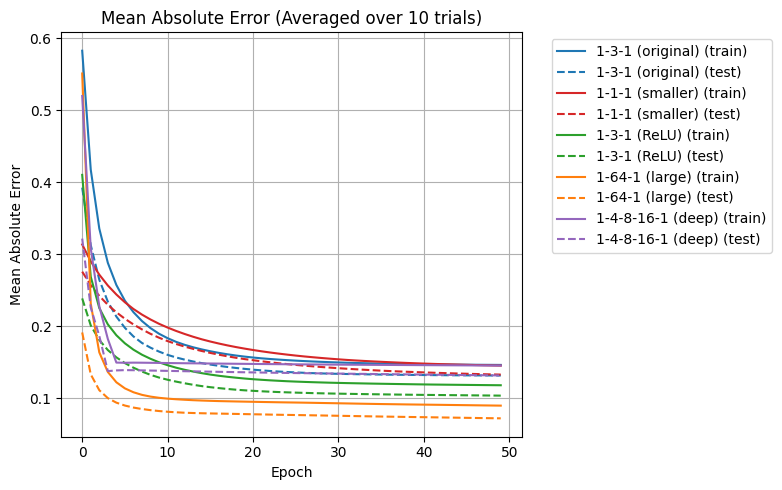

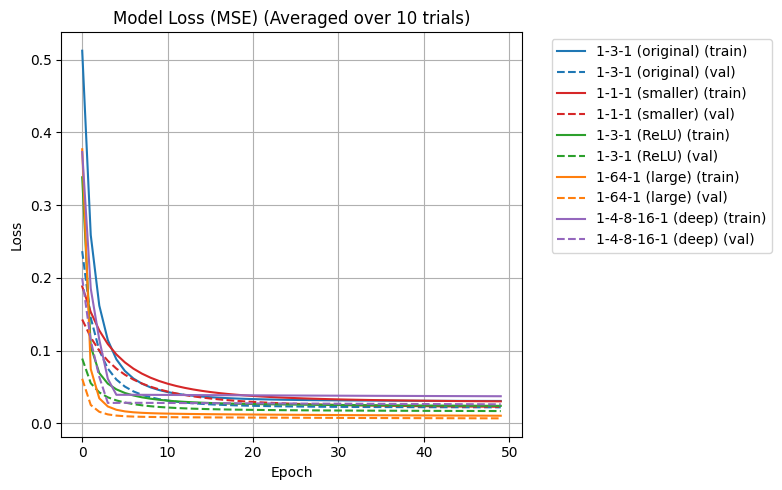

In [35]:
# Create figure for MAE
plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

for i, (name, history) in enumerate(histories.items()):
    plt.plot(history['mean_absolute_error'], color=colors[i], label=f'{experiments[name]["description"]} (train)')
    plt.plot(history['val_mean_absolute_error'], '--', color=colors[i], label=f'{experiments[name]["description"]} (test)')
plt.title('Mean Absolute Error (Averaged over 10 trials)')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# Create figure for loss
plt.figure(figsize=(8, 5))
for i, (name, history) in enumerate(histories.items()):
    plt.plot(history['loss'], color=colors[i], label=f'{experiments[name]["description"]} (train)')
    plt.plot(history['val_loss'], '--', color=colors[i], label=f'{experiments[name]["description"]} (val)')
plt.title('Model Loss (MSE) (Averaged over 10 trials)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
    

## Final Results

In [36]:
# Display final metrics with standard deviation
print("Final Results (averaged over 10 trials):")
for name, history in histories.items():
   print(f"\n{experiments[name]['description']}:")
   print(f"Training MAE: {history['mean_absolute_error'][-1]:.4f} ± {history['std_mean_absolute_error'][-1]:.4f}")
   print(f"Validation MAE: {history['val_mean_absolute_error'][-1]:.4f} ± {history['std_val_mean_absolute_error'][-1]:.4f}")
   print(f"Training Loss: {history['loss'][-1]:.4f} ± {history['std_loss'][-1]:.4f}")
   print(f"Validation Loss: {history['val_loss'][-1]:.4f} ± {history['std_val_loss'][-1]:.4f}")

Final Results (averaged over 10 trials):

1-3-1 (original):
Training MAE: 0.1460 ± 0.0006
Validation MAE: 0.1313 ± 0.0005
Training Loss: 0.0307 ± 0.0001
Validation Loss: 0.0219 ± 0.0001

1-1-1 (smaller):
Training MAE: 0.1450 ± 0.0074
Validation MAE: 0.1326 ± 0.0074
Training Loss: 0.0302 ± 0.0010
Validation Loss: 0.0227 ± 0.0012

1-3-1 (ReLU):
Training MAE: 0.1178 ± 0.0170
Validation MAE: 0.1033 ± 0.0147
Training Loss: 0.0240 ± 0.0088
Validation Loss: 0.0168 ± 0.0062

1-64-1 (large):
Training MAE: 0.0894 ± 0.0026
Validation MAE: 0.0718 ± 0.0028
Training Loss: 0.0104 ± 0.0007
Validation Loss: 0.0068 ± 0.0005

1-4-8-16-1 (deep):
Training MAE: 0.1451 ± 0.0048
Validation MAE: 0.1314 ± 0.0086
Training Loss: 0.0372 ± 0.0024
Validation Loss: 0.0261 ± 0.0024
